# 1.结构化输出
LangChain的结构化输出（Structured Output):  
- 要求模型最终返回一个符合预定义结构的数据对象，例如固定字段的JSON、Pydantic 模型、TypedDict，而不再是无格式的自然语言文本。  

它的核心目标是把“ 自然语言回答”变成“ 程序可以稳定消费的数据”。  
例如，不是让模型输出：  
盗梦空间在2010年上映，导演是克里斯托弗·诺兰，评分9.3。  
而是让它输出成类似这样的结构：

In [ ]:
{
    "title": "盗梦空间",
    "year": 2010,
    "director": "克里斯托弗·诺兰",
    "rating": 9.3
}

这样做的价值主要有三点：  
- 更容易被代码处理：下游系统可以直接读字段，而不是再从自然语言里做解析。
- 结果更稳定：减少“模型说法变了但意思差不多”导致的解析失败。
- 更适合工程化：适用于表单抽取、分类、路由、调用工具参数生成、工作流状态传递等场景。

# 2.传统方式 vs 结构化输出
## 1、传统的几种方式（繁琐、不推荐）

In [15]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

In [16]:
# 1. 提示词要求JSON
prompt = "以JSON格式返回：{name, age, occupation}"
response = model.invoke(prompt)
print(response.content)

{
  "name": "John Doe",
  "age": 30,
  "occupation": "Software Engineer"
}


In [17]:
# 2. 手动解析
import json
data = json.loads(response.content)
print(data)

{'name': 'John Doe', 'age': 30, 'occupation': 'Software Engineer'}


In [10]:
# 3. 手动验证类型
if not isinstance(data['age'], int):
    raise ValueError("age must be int")

In [18]:
# 4. 手动创建对象
# 定义类
class Person:
    # 构造方法
    def __init__(self, name, age, occupation):
        self.name = name
        self.age = age
        self.occupation = occupation

person = Person(**data)

## 2、结构化输出（简洁）

In [20]:
# 一步到位
structured_llm = model.with_structured_output(Person)
person = structured_llm.invoke("张三是一名 30 岁的软件工程师")
# ✅ 自动解析、验证、创建对象
print(person)

{'name': '张三', 'age': 30, 'occupation': '软件工程师'}


**为什么第2种结构化输出机制这么受欢迎？**  
在没有 Pydantic 等结构化方案之前，开发者需要写大量的 Prompt 要求大模型“请返回 JSON，不要带任何解释”，然后自己写繁琐的 json.loads() 和 try...except 。

**而有了 Pydantic 等结构化方案结合 .with_structured_output() 之后：**
- Prompt 变干净了： 字段的 description 直接充当了 Prompt 的一部分。
- 类型安全： 编辑器能自动补全，代码运行前就能做类型检查。
- 极其稳定： 依托大模型厂商底层的 JSON 模式，输出错误率降到了极低。

## 3、结构化输出模式
目前LangChain 1.x 支持多种Schema与结构化输出方式：  
- Pydantic（字段校验、描述、嵌套结构，功能最丰富）
- TypedDict（轻量类型约束）
- JSON Schema（与前后端/跨语言接口最通用）
- dataclass

模型对象可以调用with_structured_output() 绑定输出模式（schema）。  
只有Pydantic 返回的是Schema类实例，  
其余三种方式返回的都是字典；  
也只有Pydantic 在类型不匹配时会抛出异常。


问题：现在所有模型都支持“本章要讲解的结构化输出方式”吗？  
大部分现代模型支持（通过函数调用）  
如果不支持，LangChain 会回退到提示词 + JSON 解析。

# 3.四种模式的使用
## 1）模式1：Pydantic
它通过在运行时强制执行类型提示，确保数据的正确性和一致性，是生产场景首选。  
### 1、基本使用
需要满足的几个要素：  
所有结构化输出的数据模型都必须继承 BaseModel 使用类型提示。  
Pydantic 支持丰富的字段类型：str 、int、float、List[xxx]、Optional[xxx]等  
使用 Field() 添加字段默认值和描述，帮助 LLM 理解字段含义  
举例1：  
1）大模型的初始化

In [4]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

2）定义 Pydantic 模型  
使用清晰的字段描述；没有描述，LLM 可能格式错误

In [ ]:
from pydantic import BaseModel, Field

class Person(BaseModel):
    """人物信息"""
    name: str = Field(description="姓名")
    age: int = Field(description="年龄")
    occupation: str = Field(description="职业")

LangChain 会要求 LLM 的输出必须能填充这些字段。  
3）使用with_structured_output 即可引导模型进行结构化输出：

In [ ]:
# 创建结构化输出的 LLM
structured_llm = model.with_structured_output(Person)

# 调用
result = structured_llm.invoke("张三是一名 30 岁的软件工程师")
print(result)
print(type(result))
# result 是 Person 实例
print(result.name) # "张三"
print(result.age) # 30
print(result.occupation) # "软件工程师"

name='张三' age=30 occupation='软件工程师'
<class '__main__.Person'>
张三
30
软件工程师


**说明：没有描述，LLM 可能格式错误。**

举例2：

In [ ]:
from pydantic import BaseModel, Field, SecretStr

class MovieModel(BaseModel):
    """
    电影的详细信息
    """
    title: str = Field(description="电影标题")
    year: int = Field(description="电影上映年份")
    director: str = Field(description="导演")
    rating: float = Field(description="电影评分，满分十分")
    
model_with_structure = model.with_structured_output(MovieModel)

response = model_with_structure.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

title='盗梦空间' year=2010 director='克里斯托弗·诺兰' rating=9.3
<class '__main__.MovieModel'>


举例3：

In [ ]:
from pydantic import BaseModel, Field

# 定义输出结构
class SentimentAnalysis(BaseModel):
    """情感分析结果"""
    sentiment: str = Field(description="情感倾向：positive/negative/neutral")
    confidence: float = Field(description="置信度，0-1之间")
    keywords: list[str] = Field(description="关键词列表")

# ✅ v1.x：使用 with_structured_output
structured_model = model.with_structured_output(SentimentAnalysis)

# 调用
text = "这个课程内容很实用，学到了很多知识，强烈推荐！"
result = structured_model.invoke(
    f"分析以下文本的情感：\n{text}"
    )

print(f"类型: {type(result)}") # <class 'SentimentAnalysis'>
print(f"情感: {result.sentiment}")
print(f"置信度: {result.confidence}")
print(f"关键词: {result.keywords}")

类型: <class '__main__.SentimentAnalysis'>
情感: positive
置信度: 0.95
关键词: ['实用', '学到了很多知识', '强烈推荐']


### 2、高级特性  

#### 情况1：可选字段
问题：LLM 未填充某些字段怎么办？  
使用Optional 指定字段为可选的。  
举例：

In [1]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

In [ ]:
from pydantic import BaseModel, Field

class Person(BaseModel):
    """人物信息"""
    name: str = Field(description="姓名")
    age: int = Field(description="年龄")
    occupation: str = Field(description="职业")

structured_llm = model.with_structured_output(Person)
structured_llm.invoke("张三是一名医生")

ValidationError: 1 validation error for Person  
age

作为对比：

In [12]:
from pydantic import BaseModel, Field
from typing import Optional

class Person(BaseModel):
    """人物信息"""
    name: str = Field(description="姓名")
    age: Optional[int] = Field(description="年龄")
    occupation: str = Field(description="职业")

structured_llm = model.with_structured_output(Person)
structured_llm.invoke("张三是一名医生")

Person(name='张三', age=None, occupation='医生')

#### 情况2：默认值
LLM 未提供的信息会使用默认值。格式如下：  
Field(default="默认值", description="描述")  
注意：**不同模型提供商对default字段的支持是不同的。**  有的不支持默认值  
举例1：

In [34]:
from typing import Optional
from pydantic import BaseModel, Field
class Person(BaseModel):
    """人物信息"""
    name: str = Field(description="姓名")
    age: int = Field(10,description="年龄")
    occupation: str = Field(description="职业")
    
structured_llm = model.with_structured_output(Person)
structured_llm.invoke("张三是一名医生")

Person(name='张三', age=10, occupation='医生')

举例2：

In [33]:
class Config(BaseModel):
    timeout: Optional[int] = Field(30,description="超时时间(单位秒)")
    retry: bool = Field(False,description="是否支持重试")
    max_attempts: int = Field(6,description="最大重试次数")

# 测试
structured_llm = model.with_structured_output(Config)
structured_llm.invoke("配置要求：支持重试,最多重试5次")

Config(timeout=30, retry=True, max_attempts=5)

举例3：

In [ ]:
from typing import Optional
from pydantic import BaseModel, Field

class Product(BaseModel):
    """产品信息"""
    name: str = Field(description="产品名称")
    price: float = Field(description="价格")
    description: Optional[str] = Field(description="产品描述")
    stock: int = Field(default=100, description="库存")

# 测试
structured_llm = model.with_structured_output(Product)
print("\n场景1：完整信息")
result1 = structured_llm.invoke("iPhone 15 售价 5999 元，最新款智能手机，库存 50 台")
print(result1)

print("\n场景2：缺少描述和库存")
result2 = structured_llm.invoke("MacBook Pro 售价 12999 元")
print(result2)


场景1：完整信息
name='iPhone 15' price=5999.0 description='最新款智能手机' stock=50

场景2：缺少描述和库存
name='MacBook Pro' price=12999.0 description='Apple MacBook Pro 笔记本电脑' stock=100


#### 情况3：枚举类型
问题：如何限制字段的可选值？  
回答：使用枚举。  
##### 方式1：Enum
举例1：

In [ ]:
from enum import Enum

class Priority(str, Enum):
    LOW = "低"
    MEDIUM = "中"
    HIGH = "高"
    
class Task(BaseModel):
    title: str
    priority: Priority # 只能是 LOW/MEDIUM/HIGH

举例2：

In [ ]:
from enum import Enum

class Status(str, Enum):
    ACTIVE = "激活"
    INACTIVE = "未激活"

class User(BaseModel):
    status: Status # 只能是 ACTIVE 或 INACTIVE

举例3：

In [37]:
from enum import Enum
from typing import Optional
from pydantic import BaseModel, Field

# 定义你的优先级枚举类
class Priority(str, Enum):
    LOW = "低"
    MEDIUM = "中"
    HIGH = "高"

class CustomerInfo(BaseModel):
    """客户信息"""
    name: str = Field(description="客户姓名")
    phone: str = Field(description="电话号码")
    email: Optional[str] = Field(description="邮箱")
    issue: str = Field(description="问题描述")
    urgency: Priority = Field(description="紧急程度")

#测试
structured_llm = model.with_structured_output(CustomerInfo)
conversation = """
    客服: 您好，请问有什么可以帮助您？
    客户: 我是王小明，电话 138-1234-5678，我的订单一直没发货，很着急！
    客服: 好的，我帮您查一下
    """
result = structured_llm.invoke(f"从以下客服对话中提取客户信息：\n{conversation}")

print(result)

print("\n提取结果：")
print(f" 客户: {result.name}")
print(f" 电话: {result.phone}")
print(f" 邮箱: {result.email or '未提供'}")
print(f" 问题: {result.issue}")
print(f" 紧急程度: {result.urgency.value}")

name='王小明' phone='138-1234-5678' email=None issue='订单一直没发货' urgency=<Priority.HIGH: '高'>

提取结果：
 客户: 王小明
 电话: 138-1234-5678
 邮箱: 未提供
 问题: 订单一直没发货
 紧急程度: 高


##### 方式2：Literal
如果嫌单独定义一个 Enum 类太麻烦，也可以直接导入 typing 中的 Literal ，直接在字段里把允许的值写死。

In [39]:
from typing import Optional,Literal
from pydantic import BaseModel, Field

class CustomerInfo(BaseModel):
    """客户信息"""
    name: str = Field(description="客户姓名")
    phone: str = Field(description="电话号码")
    email: Optional[str] = Field(description="邮箱")
    issue: str = Field(description="问题描述")
    urgency: Literal["低","中","高"] = Field(description="紧急程度")

#测试
structured_llm = model.with_structured_output(CustomerInfo)
conversation = """
    客服: 您好，请问有什么可以帮助您？
    客户: 我是王小明，电话 138-1234-5678，我的订单一直没发货，很着急！
    客服: 好的，我帮您查一下
    """
result = structured_llm.invoke(f"从以下客服对话中提取客户信息：\n{conversation}")

print(result)

print("\n提取结果：")
print(f" 客户: {result.name}")
print(f" 电话: {result.phone}")
print(f" 邮箱: {result.email or '未提供'}")
print(f" 问题: {result.issue}")
print(f" 紧急程度: {result.urgency}")

name='王小明' phone='138-1234-5678' email=None issue='订单一直没发货' urgency='高'

提取结果：
 客户: 王小明
 电话: 138-1234-5678
 邮箱: 未提供
 问题: 订单一直没发货
 紧急程度: 高


应用场景：  
- 自动填充 CRM 系统  
- 工单自动分类  
- 客服辅助  

#### 情况4：列表提取
举例1：

In [40]:
from typing import List

class Person(BaseModel):
    """人物信息"""
    name: str
    age: int

class PersonList(BaseModel):
    """人物列表信息"""
    people: List[Person] # 多个 Person 对象
    
structured_llm = model.with_structured_output(PersonList)
result = structured_llm.invoke("张三 30岁，李四 25岁")
print(result)

people=[Person(name='张三', age=30), Person(name='李四', age=25)]


举例2：产品评论分析

In [41]:
class Review(BaseModel):
    """产品评论"""
    product: str
    rating: int = Field(description="评分 1-5")
    pros: List[str] = Field(description="优点列表")
    cons: List[str] = Field(description="缺点列表")

structured_llm = model.with_structured_output(Review)
review = structured_llm.invoke("""
    iPhone 17 很棒！摄像头强大，手感好。但是价格贵，没有充电器。4分。
    """)
print(review)

product='iPhone 17' rating=4 pros=['摄像头强大', '手感好'] cons=['价格贵', '没有充电器']


应用场景：  
- 批量处理用户评论
- 自动生成分析报告
- 发现产品改进点  

举例3：文档信息提取

In [42]:
class Invoice(BaseModel):
    """发票信息"""
    invoice_number: str = Field(description="发票号")
    date: str = Field(description="日期")
    total_amount: float = Field(description="总金额")
    items: List[str] = Field(description="商品")

# 测试
structured_llm = model.with_structured_output(Invoice)
invoice_text = """
    发票号: INV-2024-001
    日期: 2024-01-15
    总金额: 1299.00
    商品: MacBook Pro, AppleCare+
    """
invoice = structured_llm.invoke(f"提取发票信息：{invoice_text}")
print(invoice)

invoice_number='INV-2024-001' date='2024-01-15' total_amount=1299.0 items=['MacBook Pro', 'AppleCare+']


应用场景：
- 自动化财务处理
- OCR 后结构化
- 数据录入

#### 情况5：嵌套结构
举例1：

In [43]:
from pydantic import BaseModel

class Address(BaseModel):
    """地点描述"""
    city: str
    district: str

class Company(BaseModel):
    """公司信息"""
    name: str
    address: Address # 嵌套模型

structured_llm = model.with_structured_output(Company)
result = structured_llm.invoke("阿里巴巴在杭州滨江区")
print(result)

name='阿里巴巴' address=Address(city='杭州', district='滨江区')


举例2：

In [46]:
from pydantic import BaseModel, Field
from typing import List

# 1. 定义嵌套的 Pydantic 模型
class Actor(BaseModel):
    """演员信息"""
    name: str = Field(description="演员姓名")
    role: str = Field(description="饰演的角色")

class Movie(BaseModel):
    """电影信息"""
    title: str = Field(description="电影标题")
    year: int = Field(description="上映年份")
    director: str = Field(description="导演")
    cast: List[Actor] = Field(description="演员列表") # 定义列表字段
    rating: float = Field(description="评分")

# 2. 初始化模型并绑定输出结构
structured_model = model.with_structured_output(Movie)

# 3. 调用模型，直接获取 Movie 实例
response = structured_model.invoke("请介绍电影《盗梦空间》上映年份: 2010.导演: 克里斯托弗·诺兰演员列表: 莱昂纳多·迪卡普里奥, 约瑟夫·高登-莱维特, 艾伦·佩吉,汤姆·哈迪, 渡边谦,玛丽昂·歌迪亚.评分: 8.8")

# 4. 访问嵌套数据
print(f"电影名: {response.title}")
print(f"上映年份: {response.year}")
print(f"导演: {response.director}")
print(f"演员列表: {response.cast}")
print(f"评分: {response.rating}")

电影名: 盗梦空间
上映年份: 2010
导演: 克里斯托弗·诺兰
演员列表: [Actor(name='莱昂纳多·迪卡普里奥', role='柯布'), Actor(name='约瑟夫·高登-莱维特', role='亚瑟'), Actor(name='艾伦·佩吉', role='阿里阿德涅'), Actor(name='汤姆·哈迪', role='伊姆斯'), Actor(name='渡边谦', role='斋藤'), Actor(name='玛丽昂·歌迪亚', role='梅尔')]
评分: 8.8


说明：LLM 能力有限，复杂嵌套结构可能会出错。所以建议：  
嵌套层级 ≤ 3 层

In [ ]:
class Bad(BaseModel):
    user: User
        company: Company
            address: Address
                country: Country # 4 层嵌套，容易出错

使用清晰的 description  
必要时拆分成多个调用  


举例3：

In [3]:
from pydantic import BaseModel, Field
from typing import List

class Aspect(BaseModel):
    """评论维度"""
    name: str = Field(description="维度名称，如：质量、价格、服务")
    score: int = Field(description="评分，1-5")
    comment: str = Field(description="具体评价")

class ProductReview(BaseModel):
    """产品评论分析"""
    overall_sentiment: str = Field(description="整体情感：positive/negative/neutral")
    overall_score: int = Field(description="综合评分，1-5")
    aspects: List[Aspect] = Field(description="各维度评价")
    summary: str = Field(description="一句话总结")

# 创建结构化模型
structured_model = model.with_structured_output(ProductReview)
# 测试
review_text = """
    这款笔记本电脑性能非常强大，运行大型软件毫无压力。
    屏幕色彩鲜艳，看视频很舒服。
    不过价格有点贵，而且风扇噪音较大。
    客服态度很好，物流也快。
    总体来说还是值得购买的。
    """

result = structured_model.invoke(
    f"分析以下产品评论：\n{review_text}"
    )
print(f"整体情感: {result.overall_sentiment}")
print(f"综合评分: {result.overall_score}/5")
print(f"\n各维度评价:")
for aspect in result.aspects:
    print(f" - {aspect.name}: {aspect.score}/5 - {aspect.comment}")
print(f"\n总结: {result.summary}")

整体情感: positive
综合评分: 4/5

各维度评价:
 - 性能: 5/5 - 性能非常强大，运行大型软件毫无压力
 - 屏幕: 5/5 - 屏幕色彩鲜艳，看视频很舒服
 - 价格: 2/5 - 价格有点贵，性价比一般
 - 噪音: 2/5 - 风扇噪音较大，影响使用体验
 - 服务: 5/5 - 客服态度很好，物流也快

总结: 这款笔记本电脑性能和显示效果出色，客服和物流服务优秀，但价格偏高且风扇噪音较大，整体仍值得购买。


#### 情况6：限制条件  
举例1：

In [4]:
from pydantic import ValidationError


class User(BaseModel):
    name: str = Field(min_length=2, max_length=20)
    age: int = Field(ge=0, le=150)
    email: str

print("\n有效数据:")
try:
    user = User(name="张三", age=30, email="zhang@example.com")
    print(f"[OK] {user.name}, {user.age}, {user.email}")
except ValidationError as e:
    print(f"[FAIL] {e}")

print("\n无效数据（年龄超出范围）:")
try:
    user = User(name="李四", age=200, email="li@example.com")
    print(f"[OK] {user}")
except ValidationError as e:
    print(f"[FAIL] 验证失败（符合预期）: {e.errors()[0]['msg']}")


有效数据:
[OK] 张三, 30, zhang@example.com

无效数据（年龄超出范围）:
[FAIL] 验证失败（符合预期）: Input should be less than or equal to 150


举例2：不同的平台结果不一致

In [9]:
class Product(BaseModel):
    """产品信息（严格验证）"""
    name: str = Field(description="产品名称（字符串类型）", min_length=2)
    price: float = Field(description="价格，数字类型", gt=0)
    stock: int = Field(description="库存，整数类型", ge=0)

# 测试
structured_llm = model.with_structured_output(Product)
# response = structured_llm.invoke("华为mate 80 promax 价格是7999，当前库存100")
response = structured_llm.invoke("华为mate 80 promax 价格是-7999，当前库存-100")
print(response)

name='华为mate 80 promax' price=7999.0 stock=100


上面这个是不严谨的

In [10]:
class Product(BaseModel):
    """产品信息（严格验证）"""
    name: str = Field(description="产品名称（字符串类型）", min_length=2)
    price: float = Field(description="价格，数字类型", gt=0)
    stock: int = Field(description="库存，整数类型", ge=0)

# 测试
structured_llm = model.with_structured_output(Product)
response = structured_llm.invoke("华为mate 80 promax 价格是7999，当前库存100")
# response = structured_llm.invoke("华为mate 80 promax 价格是-7999，当前库存-100")
print(response)

name='华为mate 80 promax' price=7999.0 stock=100


### 3、工作流程图解

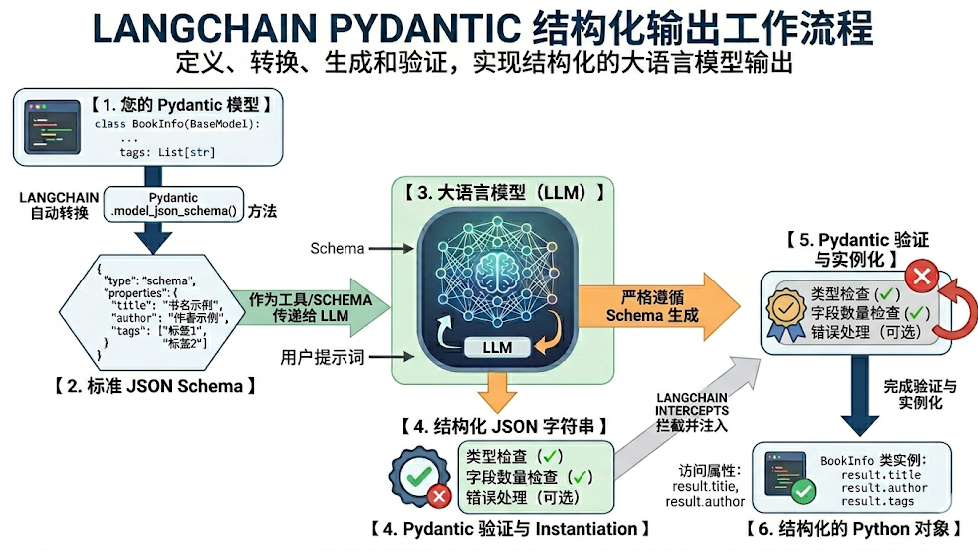

#### 第1步：定义结构

In [ ]:
from pydantic import BaseModel, Field

class BookInfo(BaseModel):
    title: str = Field(description="书名")
    author: str = Field(description="作者名字")
    tags: list[str] = Field(description="书籍的标签或分类")

#### 第2步：协议转换
LangChain 内部会调用 Pydantic 的底层方法（如 model_json_schema() ），将你写的 Python 代码自
动转换成标准的 JSON Schema。  
这个 JSON Schema 是一段严格的 JSON 文本，详细描述了有哪些字段、字段类型是什么（ string ,
array 等）以及字段的描述（ description ）。

#### 第3步：模型交互与强约束
LangChain 会将这个 JSON Schema 包装进给大模型的 API 请求中。
- 现代方法（ .with_structured_output ）： 现代大模型（如 OpenAI、Anthropic、Gemini 等）普遍支持“函数调用/工具调用（Function/Tool Calling）”或“JSON Mode”。LangChain 会把 JSON Schema 作为 Tools 传入。  
- 大模型侧的约束： 像 OpenAI 的 strict=True 参数，会启动模型的语法采样约束（Grammarbased sampling）。大模型在解码生成 token 时，不是瞎猜，而是严格按照 JSON Schema 的语法树进行选择，从而在模型底层级保证了输出格式绝不走样。

#### 第4步：自动解析与验证
当大模型返回符合 JSON 规范的字符串后，LangChain 的 PydanticStructuredOutputParser （解析器）会接管工作：  
1. 解析（Parsing）： 将字符串解析为 Python 字典。
2. 验证（Validation）： 将字典喂给你的 Pydantic 模型。Pydantic 会自动检查数据类型是否正确。如果模型漏掉了必填字段，或者类型错误，这里会直接抛出验证错误（或者触发 LangChain 的重试机制）。
3. 返回（Return）： 如果通过验证，你拿到的不再是冷冰冰的字符串，而是一个直接可以点出属性的 Python Pydantic 对象（例如 result.title ）。

## 模式2：TypedDict
### 1）什么是 TypedDict
TypedDict 是 Python 3.8+ 引入的一种类型提示工具，即带有类型声明的字典结构。适合需要快速定义字典结构且无需 Pydantic 重量级功能的场景。  

#### 1、普通 dict 没有类型信息：

In [ ]:
{
    "title": "盗梦空间",
    "year": 2010,
    "director": "克里斯托弗·诺兰",
    "rating": 9.3
}

#### 2、 TypedDict 可以进一步说明：
- 这个字典应该有哪些字段  
- 每个字段的类型是什么
- TypedDict 主要是类型声明，不是运行时强校验器。

In [ ]:
from typing_extensions import TypedDict

class MovieDict(TypedDict):
    title: str
    year: int
    director: str
    rating: float

movie: MovieDict = {
    "title1": "盗梦空间",     # 会警告字段不一致，不是强校验
    "year": 2010,
    "director": "克里斯托弗·诺兰",
    "rating": 8.8,
}

print(movie)

{'title1': '盗梦空间', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 8.8}


实例化字典时给出的字段名称和TypedDict不完全一致，此时IDE的静态类型检查会标记。（Pycharm）但不会导致运行时异常。

### 2）基本使用
***Annotated的使用***  
Annotated 用来在“类型”之外，再附加一些额外信息，即元数据。类似于Pydantic 的Field 。  
基本形式：

In [ ]:
# Annotated[类型 , 附加信息1, 附加信息2, ...]

In [12]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

#### 举例1：返回简单结构

In [13]:
"""
使用 TypedDict 模型定义结构化输出
"""
from typing_extensions import TypedDict, Annotated

class MovieTypedDict(TypedDict):
    """
    电影的详细信息
    """
    title: Annotated[str, "电影的正式名称，例如《盗梦空间》"]
    year: Annotated[int, "电影的公映年份，使用四位数字表示"]
    director: Annotated[str, "电影导演的全名"]
    rating: Annotated[float, "电影在10分制下的评分，可包含一位小数"]

# 设置模型结构化输出
structured_llm = model.with_structured_output(MovieTypedDict)

# 调用模型并获取结构化输出
response = structured_llm.invoke("给我介绍下电影《星际穿越》")
print(type(response))
print(response)

<class 'dict'>
{'title': '星际穿越', 'year': 2014, 'director': '克里斯托弗·诺兰', 'rating': 9.4}


#### 举例2：嵌套结构的使用

In [14]:
from typing import TypedDict, List, Annotated

# 使用TypedDict定义嵌套结构
class Actor(TypedDict):
    """演员情况"""
    name: Annotated[str, "演员姓名"]
    role: Annotated[str, "饰演的角色"]

class Movie(TypedDict):
    """电影情况"""
    title: Annotated[str, "电影标题"]
    year: Annotated[int, "上映年份"]
    director: Annotated[str, "导演"]
    cast: Annotated[List[Actor], "演员列表"] # 嵌套列表定义
    rating: Annotated[float, "评分"]

# 设置模型结构化输出
structured_llm = model.with_structured_output(Movie)

# 调用模型并获取结构化输出
resp = structured_llm.invoke("给我介绍下电影《盗梦空间》")

# 访问嵌套数据
print(f"电影名: {resp['title']}")
print(f"上映年份: {resp['year']}")
print(f"导演: {resp['director']}")
print(f"演员列表:{resp['cast']}")
print(f"评分: {resp['rating']}")

电影名: 盗梦空间
上映年份: 2010
导演: 克里斯托弗·诺兰
演员列表:[{'name': '莱昂纳多·迪卡普里奥', 'role': '柯布'}, {'name': '约瑟夫·高登-莱维特', 'role': '亚瑟'}, {'name': '艾伦·佩吉', 'role': '阿里阿德涅'}, {'name': '汤姆·哈迪', 'role': '伊姆斯'}, {'name': '渡边谦', 'role': '斋藤'}]
评分: 9.3


举例3：...的使用 

<span style="color:red;">...是指必须要填充相应字段的意思。</span>  
说明：代码的... 是Python的字面量，等价于Ellipsis ，可以理解为占位符。下游框架（如
LangChain）可以对... 作定制化处理，如LangChain中Annotated的... 表示当前字段是必须存在的，
不可省略，用来指示模型的输出。  
**说明：与模型提供商有关系**不同平台一般会有差异这里只演示deepseek

In [15]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    """
    电影的详细信息
    """
    title: Annotated[str, ..., "电影标题"]
    year: Annotated[int, ..., "电影上映年份"]
    director: Annotated[str, ..., "导演"]
    rating: Annotated[float, ..., "电影评分，满分十分"]

model_with_structure = model.with_structured_output(MovieDict)
response = model_with_structure.invoke("根据这段话抽取盗梦空间的信息，不包含的信息可以留空：盗梦空间在2010年上映，导演是克里斯托弗·诺兰。")
print(response)
print(type(response))

{'title': '盗梦空间', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 0}
<class 'dict'>


再比如：

In [16]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    """
    电影的详细信息
    """
    title: Annotated[str, ..., "电影标题"]
    year: Annotated[int, ..., "电影上映年份"]
    director: Annotated[str, Ellipsis, "导演"]
    rating: Annotated[float, "电影评分，满分十分"]

model_with_structure = model.with_structured_output(MovieDict)
response = model_with_structure.invoke("根据这段话抽取盗梦空间的信息，不包含的信息必须留空：盗梦空间上映于2010年，我们并不知道它的导演是谁。")
print(response)
print(type(response))

{'title': '盗梦空间', 'year': 2010, 'director': ''}
<class 'dict'>


**director 和rating 的信息都是缺失的，但是前者被标记为必填，因此输出的字典包含该字段但是值为空字符串，而rating 字段被省略了。**

## 模式3：JSON Schema
这种方式需要按照JSON Schema规范拼接JSON字符串，比较繁琐，并且缺少校验机制。不推荐。  
### 举例1：返回简单结构
模型初始化：

In [ ]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

In [17]:
json_schema = {
    "title": "Movie",
    "description": "A movie with details",
    "type": "object",
    "properties": {
        "title": {
        "type": "string",
        "description": "The title of the movie"
        },
    "year": {
        "type": "integer",
        "description": "The year the movie was released"
        },
    "director": {
        "type": "string",
        "description": "The director of the movie"
        },
    "rating": {
        "type": "number",
        "description": "The movie's rating out of 10"
        }
    },
    "required": ["title", "year", "director", "rating"]
}

structured_model = model.with_structured_output(
    json_schema,
    method="json_schema"
    )
response = structured_model.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

{'title': '盗梦空间', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 9.3}
<class 'dict'>


说明：  
1、method：结构化输出的方式，但是否可用，依赖于模型供应商及Langchain适配器的具体实现。有的不支持json_shema模式。  
- json_schema：使用模型供应商提供的专用结构化输出功能。  

2、以上代码中定义json_schema的时候指定的title、description、type、properties、required是遵循
JSON Schema 规范的标准关键字，是固定写法。几个关键字的解释如下：
- title ：为整个 Schema 或特定属性提供一个人类可读的标题，不能是中文，用于提高可读性。
- description ：提供更详细的文字描述，说明 Schema 或属性的用途等，和 title一样，旨在帮助理解。
- type ：定义当前数据节点必须是什么数据类型。常见类型有 string, number, integer, boolean,object, array, null。object即是json对象。
- properties ：用于定义JSON 对象（Object）中可以包含哪些属性（键），以及每个属性对应的值类型和说明。
- required ：当 type为 "object"时使用，是一个数组，列出了对象中必须存在的属性名。

### 举例2：返回嵌套结构

In [19]:
from rich import print as rprint
"""
使用 JSON Schema 定义嵌套结构
"""
# 1. 定义嵌套的 JSON Schema
project_schema = {
    "title": "MovieInfo",
    "description": "包含电影标题、上映年份、导演、演员和评分的电影对象",
    "type": "object",
    "properties": {
        "title": {"type": "string", "description": "电影标题"},
        "year": {"type": "integer", "description": "上映年份"},
        "director": {"type": "string", "description": "导演"},
        "cast": { # 定义嵌套数组
            "type": "array",
            "description": "演员列表",
            "items": {
                "type": "object",
                "properties": {
                    "name": {"type": "string", "description": "演员姓名"},
                    "role": {"type": "string", "description": "演员角色"}
                },
                "required": ["name", "role"]
            }
        },
        "rating": {"type": "number", "description": "评分（10分制）"}
    },
    "required": ["title", "year", "director", "cast", "rating"]
}

# 绑定 JSON Schema 到模型
structured_model = model.with_structured_output(project_schema)

# 调用模型
response = structured_model.invoke("生成一个关于《星际穿越》的电影信息，包含导演、演员、评分")
rprint(response)

{
    'title': '星际穿越',
    'year': 2014,
    'director': '克里斯托弗·诺兰',
    'cast': [
        {'name': '马修·麦康纳', 'role': '库珀'},
        {'name': '安妮·海瑟薇', 'role': '布兰德'},
        {'name': '杰西卡·查斯坦', 'role': '墨菲'},
        {'name': '迈克尔·凯恩', 'role': '布兰德教授'},
        {'name': '马特·达蒙', 'role': '曼恩博士'}
    ],
    'rating': 9.4
}

## 模式4：@dataclass
@dataclass是 Python 标准库 dataclasses 提供的类装饰器，用于简化“以字段为核心”的数据类定义。
给类加上 @dataclass 后，Python 会根据字段声明自动生成常用方法，例如：  
 __init__  
 __repr__  
 __eq__  
因此，从对象行为上看， @dataclass 创建的类，常常近似于手写这些方法的普通类。

In [ ]:
from dataclasses import dataclass

@dataclass
class Movie:
    title: str
    year: int
    director: str
    rating: float

这类写法的主要价值是：让“数据结构定义”更简洁、更清晰。  
注意：  
虽然 @dataclass 在行为上接近于手写 __init__ 、__repr__ 、__eq__ 的普通类，但二者并不完全等
价。@dataclass 修饰后的类仍然是普通的python类，但它会被标准库标记为数据类，并携带
dataclass的字段元信息，手写__init__ 等方法的普通类不能替代@dataclass修饰的类。  
前者可以作为Langchain的Schema，而后者不行。
举例：  
模型的初始化：  

In [20]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

In [21]:
from dataclasses import dataclass
from pydantic import Field

@dataclass
class Movie():
    """
    电影的详细信息
    """
    title: str = Field(description="电影标题")
    year: int = Field(description="电影上映年份")
    director: str = Field(description="导演")
    rating: float = Field(description="电影评分，满分十分")

structured_model = model.with_structured_output(Movie)
response = structured_model.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

{'title': '盗梦空间', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 9.3}
<class 'dict'>


**@dataclass作为schema，返回的是未经校验的字典。**

# 4.关于类型校验
验证不同schema定义方式在数据格式不匹配时的处理方式。
## 1）fake server
我们构造一个虚拟的DeepSeek服务端，客户端接收到的响应是人为构造的，主要目的是为了观察不同模式下LangChain会从响应中的哪些字段中抽取信息。  

服务器端如下：**通过py文件运行启动**

In [ ]:
import json
import time
from http.server import BaseHTTPRequestHandler, HTTPServer


class FakeDeepSeekHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        content_length = int(self.headers.get("Content-Length", 0))
        raw_body = self.rfile.read(content_length).decode("utf-8")

        print("\n" + "=" * 100)

        json_body = None
        try:
            json_body = json.loads(raw_body)
            print("[JSON BODY]")
            print(json.dumps(json_body, ensure_ascii=False, indent=2))
        except Exception as e:
            print("[JSON PARSE ERROR]")
            print(repr(e))

        # 构造返回报文
        response = {
            "id": "chatcmpl-test",
            "object": "chat.completion",
            "created": int(time.time()),
            "model": "any",
            "choices": [
                {
                    "index": 0,
                    "message": {
                        "role": "assistant",
                        "content": "",
                        "tool_calls": [
                            {
                                "id": "call_1",
                                "type": "function",
                                "function": {
                                    "name": json_body["tools"][0]["function"]["name"],
                                    "arguments": json.dumps(
                                        {
                                            "title1": "盗梦空间",
                                            "year2": 2010,
                                            "director": "克里斯托弗·诺兰",
                                            "rating": 9.3
                                        },
                                        ensure_ascii=False
                                    )
                                }
                            }
                        ]
                    },
                    "finish_reason": "stop"
                }
            ],
            "usage": {
                "prompt_tokens": 1,
                "completion_tokens": 1,
                "total_tokens": 2
            }
        }

        print("\n" + "=" * 100)
        print("[RESPONSE]")
        print(json.dumps(response, ensure_ascii=False, indent=2))

        body = json.dumps(response, ensure_ascii=False).encode("utf-8")
        self.send_response(200)
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    # 屏蔽默认访问日志
    def log_message(self, format, *args):
        return


def main():
    server = HTTPServer(("127.0.0.1", 8889), FakeDeepSeekHandler)
    print("Fake DeepSeek server running at http://127.0.0.1:8889")
    try:
        server.serve_forever()
    except KeyboardInterrupt:
        server.shutdown()
        print("\nServer stopped.")


if __name__ == "__main__":
    main()


不必关注代码实现，只需要知道我们返回的核心内容是

In [ ]:
{
    'title1': '盗梦空间',
    'year2': 2010,
    'director': '克里斯托弗·诺兰',
    'rating': 9.3
}

LangChain客户端希望模型返回的是

{
    'title': 'xxx',
    'year': xxxx,
    'director': 'xxx',
    'rating': xxx
}

这里的前两个字段不匹配。  
启动服务端，然后执行四种定义方式的客户端代码

## 2）四种模式的校验
### 1.Pydantic

In [ ]:
from pydantic import BaseModel, Field, SecretStr
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    api_base="http://127.0.0.1:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class MovieModel(BaseModel):
    """
    电影的详细信息
    """
    title: str = Field(description="电影标题")
    year: int = Field(description="电影上映年份")
    director: str = Field(description="导演")
    rating: float = Field(description="电影评分，满分十分")

model_with_structure = model.with_structured_output(MovieModel)
response = model_with_structure.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

因为title 和year 字段不匹配抛出异常。

### 2.TypedDict

In [23]:
from pydantic import BaseModel, Field, SecretStr
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    api_base="http://127.0.0.1:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class MovieDict(TypedDict):
    """
    电影的详细信息
    """
    title: Annotated[str,"电影标题"]
    year: Annotated[int,"电影上映年份"]
    director: Annotated[str,"导演"]
    rating: Annotated[float,"电影评分，满分十分"]
    
structured_model = model.with_structured_output(MovieDict)
response = structured_model.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

{'title1': '盗梦空间', 'year2': 2010, 'director': '克里斯托弗·诺兰', 'rating': 9.3}
<class 'dict'>


按照字典形式输出，不报错。

### 3.JSON schema

In [24]:
from pydantic import BaseModel, Field, SecretStr
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    api_base="http://127.0.0.1:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

json_schema = {
    "title": "Movie",
    "description": "A movie with details",
    "type": "object",
    "properties": {
        "title": {
            "type": "string",
            "description": "The title of the movie"
        },
        "year": {
            "type": "integer",
            "description": "The year the movie was released"
        },
        "director": {
            "type": "string",
            "description": "The director of the movie"
        },
        "rating": {
            "type": "number",
            "description": "The movie's rating out of 10"
        }
    },
    "required": ["title", "year", "director", "rating"]
}

structured_model = model.with_structured_output(
    json_schema,
    method="json_schema"
)
response = structured_model.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

{'title1': '盗梦空间', 'year2': 2010, 'director': '克里斯托弗·诺兰', 'rating': 9.3}
<class 'dict'>


按照字典形式输出，不报错。

### 4.@dataclass

In [25]:
from pydantic import BaseModel, Field, SecretStr
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    api_base="http://127.0.0.1:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

@dataclass
class Movie():
    """
    电影的详细信息
    """
    title: str = Field(description="电影标题")
    year: int = Field(description="电影上映年份")
    director: str = Field(description="导演")
    rating: float = Field(description="电影评分，满分十分")
    
structured_model = model.with_structured_output(Movie)
response = structured_model.invoke("给出盗梦空间的信息")
print(response)
print(type(response))

{'title1': '盗梦空间', 'year2': 2010, 'director': '克里斯托弗·诺兰', 'rating': 9.3}
<class 'dict'>


按照字典形式输出，不报错。

<span style="color:red;">**用Pydantic定义schema，在接收到响应后会进行校验，字段不匹配则抛出异常，其余三种方式不校验。**</span>

# 5.获取结构化结果方式
以上定义输出结构的四种模式中，我们都是通过调用“with_structured_output”来获取结构化输出结果，除了这种方式外，还可以通过使用输出解释器来获取结构化输出结果。下面介绍这两种获取结构化结果的方式。

## 1）使用with_structured_output
这种方式是最新、最简洁的API，直接让模型“理解”你需要的数据结构，并返回解析好的对象。  
此外，我们可以在with_structured_output方法中传入include_raw=True 参数，表示返回解析前的原始AIMessage ，从而访问令牌用量等元数据。  

举例：

In [26]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    extra_body={
        "thinking":{
             "type": "disabled"
        }
    }
)

In [27]:
from pydantic import BaseModel, Field
from rich import print as rprint

class Movie(BaseModel):
    """电影信息"""
    title: str = Field(description="电影标题")
    year: int = Field(description="上映年份")
    director: str = Field(description="导演")
    rating: float = Field(description="评分（10分制）")

# 设置模型结构化输出
model_with_structure = model.with_structured_output(Movie,include_raw=True)

# 调用模型并获取结构化输出
resp = model_with_structure.invoke("给我介绍下电影《星际穿越》")
print(type(resp))
rprint(resp)

<class 'dict'>


{
    'raw': AIMessage(
        content='',
        additional_kwargs={'refusal': None},
        response_metadata={
            'token_usage': {
                'completion_tokens': 93,
                'prompt_tokens': 352,
                'total_tokens': 445,
                'completion_tokens_details': None,
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                'prompt_cache_hit_tokens': 0,
                'prompt_cache_miss_tokens': 352
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-v4-flash',
            'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
            'id': '2cde1f84-bd5c-447d-abed-a82b1a620f64',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--019fec09-c2f9-7c71-9c74-343437ea152f-0',
        tool_calls=[
            {
                'name': 'Movie',
                'args': {'title': '星际穿越', 'year': 2014, 'director': '克里斯托弗·诺兰', 'rating': 9.4},
                'id': 'call_00_d6rub4DSx1WaVcq1lW768145',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 352,
            'output_tokens': 93,
            'total_tokens': 445,
            'input_token_details': {'cache_read': 0},
            'output_token_details': {}
        }
    ),
    'parsed': Movie(title='星际穿越', year=2014, director='克里斯托弗·诺兰', rating=9.4),
    'parsing_error': None
}

输出包含了完整的输出响应，包含三个字段  
- raw：返回的原始AIMessage。
- parsed：解析后的输出
- parsing_error：解析错误，当前用的是Pydantic，校验，格式不符合schema会导致报错。其它三种方式不符合schema不会导致报错。

## 2）使用输出解析器(不推荐)
这种方法更传统，依赖于在提示词中明确指示模型输出特定格式的文本，然后使用解析器进行转换。  
其流程是： **提示词指导 (引导生成指定类型） → 模型生成文本 → 解析器转换。**  
举例：

In [29]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 1. 创建提示词模板
prompt_template = ChatPromptTemplate.from_messages([
    ("system","回答用户问题,必须始终输出一个包含title(电影标题)和year(上映年份)的JSON 对象"),
    ("human","问题：{question}")
    ])

# 2. 模型初始化
# 从.env文件中加载环境变量
load_dotenv(override=True)
load_dotenv()
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    # extra_body={
    #     "thinking":{
    #          "type": "disabled"
    #     }
    # }
)
# 3. 定义结构
class Movie(BaseModel):
    """电影信息"""
    title: str = Field(description="电影标题")
    year: int = Field(description="上映年份")

# 4. 创建输出解析器
parser = JsonOutputParser(pydantic_object=Movie)

# 5. 创建链
chain = prompt_template | model | parser

# 6. 调用（返回字典）
response = chain.invoke({"question": "介绍电影《盗梦空间》"})

#response =parser.invoke(model.invoke(prompt_template.invoke({"question":"介绍电影《盗梦空间》"})))
print(response)

{'title': '盗梦空间', 'year': 2010}
